
# Functional  depth 

Sample usage of Depth for functional data.
It will plot samples and dataset based on depth notions.


In [1]:
from depth.model.DepthFunc import DepthFunc 
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
## Creating dataset and samples
np.random.seed(2801)
n_cases = 100
rows = []
# fig,(ax1,ax2,ax3)=plt.subplots(1,3,figsize=(15,5))
for case in range(1, n_cases + 1):
    n_points = 100#np.random.randint(3, 16)
    timestamps = pd.to_datetime("2024-01-01") + pd.to_timedelta(
        np.sort(np.random.randint(0, 1000, n_points)), unit='s'
    )
    baseVal = np.linspace(0,7,n_points)+np.random.normal(0,.2,n_points)
    bruit = np.random.normal(0,1,1)
    value_1 = np.cos(baseVal)+bruit
    value_2 = np.sin(baseVal)+bruit*0.5
    value_3 = np.cos(baseVal)*np.sin(baseVal**1.2)+bruit*0.5#+np.sin(baseVal)#+decVal
    
    # value_2 = np.random.rand(n_points)
    # value_3 = np.random.rand(n_points)
    value_3[-1] = None
    for t, v1, v2, v3 in zip(timestamps, value_1, value_2, value_3):
        rows.append([case, t, v1, v2, v3])
    # ax1.plot(timestamps,value_1)
    # ax2.plot(timestamps,value_2)
    # ax3.plot(timestamps,value_3)
df = pd.DataFrame(rows, columns=["case_id", "timestamp", "value_1", "value_2", "value_3"])

df.head(10)

/var/folders/jb/vgyp2lnd2l114w99s_3t_1zr0000gn/T/ipykernel_65156/2843931067.py:15: RuntimeWarning: invalid value encountered in power
  value_3 = np.cos(baseVal)*np.sin(baseVal**1.2)+bruit*0.5#+np.sin(baseVal)#+decVal


,case_id,timestamp,value_1,value_2,value_3
0,1,2024-01-01 00:00:46,0.854275,0.289880,0.211413
1,1,2024-01-01 00:00:49,0.911695,-0.038468,-0.042127
2,1,2024-01-01 00:01:02,0.843568,0.318681,0.235291
3,1,2024-01-01 00:01:44,0.756153,0.491501,0.363903
4,1,2024-01-01 00:02:04,0.751440,0.498861,0.368497
5,1,2024-01-01 00:02:10,0.883749,0.190679,0.127715
6,1,2024-01-01 00:02:23,0.730421,0.530062,0.386823
7,1,2024-01-01 00:02:38,0.667949,0.610152,0.423474
8,1,2024-01-01 00:02:42,0.370105,0.844604,0.367368
9,1,2024-01-01 00:02:52,0.704664,0.565137,0.404913


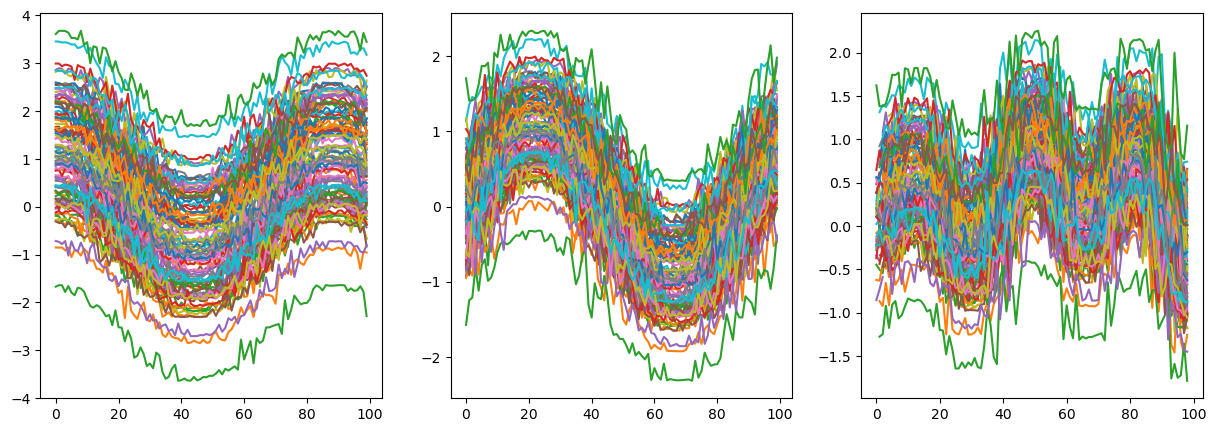

In [3]:
fig,(ax1,ax2,ax3)=plt.subplots(1,3,figsize=(15,5))
for case in range(1, n_cases + 1):
    ax1.plot(df[df.case_id==case].value_1.values)
    ax2.plot(df[df.case_id==case].value_2.values)
    ax3.plot(df[df.case_id==case].value_3.values)
plt.show()

Create model and load dataset for depth computation 



In [4]:
model=DepthFunc().load_dataset(df,interpolate_grid=False)
Dpth=model.projection_based_func_depth(df,notion="projection",output_option="lowest_depth",NRandom=1000)
print("depth of first 10 functions:" , Dpth)

timestamp_col is set to timestamp
value_cols is set to Index(['value_1', 'value_2', 'value_3'], dtype='object')
case_id is set to case_id


depth of first 10 functions: [0.3388853  0.29009489 0.21494666 0.34792041 0.25765167 0.28470119
 0.25937847 0.24050913 0.27550712 0.19849267 0.32483688 0.30455655
 0.25793978 0.26806925 0.27723243 0.24156398 0.34640756 0.25445037
 0.31343481 0.37869565 0.24025661 0.29034904 0.29705978 0.15790088
 0.20839458 0.25147152 0.26564955 0.33116326 0.30327052 0.36766294
 0.28437254 0.19088241 0.16102735 0.26368617 0.24188281 0.25022952
 0.23399113 0.28286471 0.30675224 0.25640107 0.31962641 0.17969126
 0.24907893 0.31116663 0.22636427 0.30769636 0.2912037  0.17976663
 0.19890258 0.34064447 0.32316514 0.19912518 0.26479623 0.22622901
 0.35442888 0.27347742 0.24463971 0.32774463 0.31587855 0.30867283
 0.28155623 0.23778289 0.28762713 0.26330651 0.25701127 0.2374093
 0.31025968 0.26683259 0.21011941 0.22507257 0.32026337 0.26828048
 0.17385489 0.21740104 0.23827362 0.18635567 0.37801541 0.31365577
 0.33009856 0.19140662 0.21392748 0.29589068 0.18511312 0.30980199
 0.31688997 0.27673889 0.31532046 

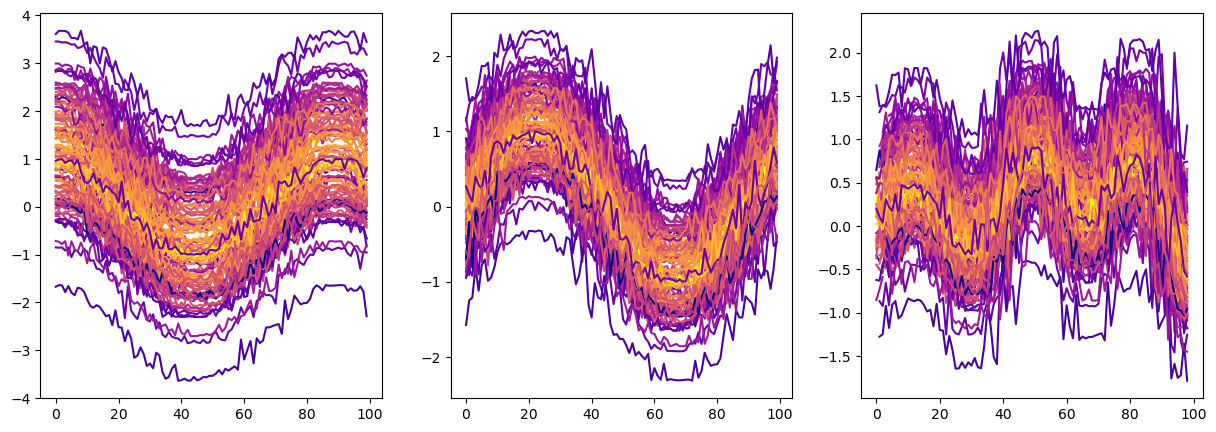

In [5]:
from matplotlib import cm
fig,(ax1,ax2,ax3)=plt.subplots(1,3,figsize=(15,5))
for case in range(1, n_cases + 1):
    ax1.plot(df[df.case_id==case].value_1.values,c=cm.plasma((Dpth[case-1]-Dpth.min())/(Dpth.max()-Dpth.min())))
    ax2.plot(df[df.case_id==case].value_2.values,c=cm.plasma((Dpth[case-1]-Dpth.min())/(Dpth.max()-Dpth.min())))
    ax3.plot(df[df.case_id==case].value_3.values,c=cm.plasma((Dpth[case-1]-Dpth.min())/(Dpth.max()-Dpth.min())))

plt.show()